In [ ]:
!pip install gdown

In [ ]:
import gdown

file_id = "1BW8BIHDFzbSwVZNhJKH2nHepPF8cRGbq"
url = f"https://drive.google.com/uc?id={file_id}"

gdown.download(url, "viddataset.zip", quiet=False)

Downloading...
From (original): https://drive.google.com/uc?id=1BW8BIHDFzbSwVZNhJKH2nHepPF8cRGbq
From (redirected): https://drive.google.com/uc?id=1BW8BIHDFzbSwVZNhJKH2nHepPF8cRGbq&confirm=t&uuid=7a6ace1c-7ced-4609-89dd-6af685474542
To: /content/viddataset.zip
100%|██████████| 2.92G/2.92G [00:35<00:00, 82.8MB/s]


'viddataset.zip'

In [ ]:
!unzip dataset.zip -d /content/dataset

Archive:  dataset.zip
   creating: /content/dataset/test/real/
  inflating: /content/dataset/test/real/00235.mp4  
  inflating: /content/dataset/test/real/00236.mp4  
  inflating: /content/dataset/test/real/00237.mp4  
  inflating: /content/dataset/test/real/00238.mp4  
  inflating: /content/dataset/test/real/00239.mp4  
  inflating: /content/dataset/test/real/00240.mp4  
  inflating: /content/dataset/test/real/00241.mp4  
  inflating: /content/dataset/test/real/00242.mp4  
  inflating: /content/dataset/test/real/00243.mp4  
  inflating: /content/dataset/test/real/00244.mp4  
  inflating: /content/dataset/test/real/00245.mp4  
  inflating: /content/dataset/test/real/00246.mp4  
  inflating: /content/dataset/test/real/00247.mp4  
  inflating: /content/dataset/test/real/00248.mp4  
  inflating: /content/dataset/test/real/00249.mp4  
  inflating: /content/dataset/test/real/00250.mp4  
  inflating: /content/dataset/test/real/00251.mp4  
  inflating: /content/dataset/test/real/00252.mp4  
 

In [ ]:
import os
os.listdir('/content/dataset')

['test', 'train', 'val']

In [ ]:
!pip install gdown
!pip install opencv-python
!pip install torch torchvision
!pip install tqdm

In [ ]:
!pip install facenet-pytorch tqdm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 43.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 96.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 118.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╸ 755.5/755.5 MB 68.0 MB/s eta 0:00:01^C


In [ ]:
!pip install torch torchvision timm opencv-python facenet-pytorch tqdm

  Using cached facenet_pytorch-2.6.0-py3-none-any.whl.metadata (12 kB)
INFO: pip is looking at multiple versions of facenet-pytorch to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 40.9 MB/s eta 0:00:00


In [ ]:
import os
import cv2
import random
import torch
import timm

from tqdm import tqdm
from PIL import Image
from facenet_pytorch import MTCNN

from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import torch.nn as nn
import torch.optim as optim

In [ ]:
dataset_path = "/content/dataset"

train_video = os.path.join(dataset_path,"train")
val_video = os.path.join(dataset_path,"val")
test_video = os.path.join(dataset_path,"test")

In [ ]:
def extract_frames(video_folder, output_folder, frames_per_video=10):

    os.makedirs(output_folder, exist_ok=True)

    for label in ["real","fake"]:

        input_path=os.path.join(video_folder,label)
        save_path=os.path.join(output_folder,label)

        os.makedirs(save_path,exist_ok=True)

        for video in tqdm(os.listdir(input_path)):

            video_path=os.path.join(input_path,video)

            cap=cv2.VideoCapture(video_path)

            total_frames=int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

            frame_ids=sorted(random.sample(range(total_frames),
                                           min(frames_per_video,total_frames)))

            current_frame=0
            saved=0

            while True:

                ret,frame=cap.read()

                if not ret:
                    break

                if current_frame in frame_ids:

                    name=video.replace(".mp4","")

                    frame_name=f"{name}_{saved}.jpg"

                    cv2.imwrite(os.path.join(save_path,frame_name),frame)

                    saved+=1

                current_frame+=1

            cap.release()

In [ ]:
extract_frames(train_video,"/content/frames/train",10)
extract_frames(val_video,"/content/frames/val",10)
extract_frames(test_video,"/content/frames/test",10)

100%|██████████| 68/68 [00:24<00:00,  2.82it/s]


FileNotFoundError: [Errno 2] No such file or directory: '/content/dataset/test/fake'

In [ ]:
extract_frames(test_video,"/content/frames/test",10)

100%|██████████| 68/68 [00:23<00:00,  2.86it/s]


In [ ]:
!rm -rf /content/frames/test/fake


In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"

mtcnn = MTCNN(keep_all=False, device=device)

In [ ]:
def extract_faces(input_dir, output_dir):

    os.makedirs(output_dir, exist_ok=True)

    for label in ["real", "fake"]:

        in_path = os.path.join(input_dir, label)
        out_path = os.path.join(output_dir, label)

        os.makedirs(out_path, exist_ok=True)

        for img in tqdm(os.listdir(in_path)):

            img_path = os.path.join(in_path, img)

            image = Image.open(img_path).convert("RGB")

            face = mtcnn(image)

            if face is not None:

                face = face.permute(1,2,0).cpu().numpy()

                # normalize to 0–255
                face = (face - face.min()) / (face.max() - face.min() + 1e-5)
                face = (face * 255).astype("uint8")

                cv2.imwrite(os.path.join(out_path, img), face[:,:,::-1])

In [ ]:
!rm -rf /content/faces

In [ ]:
extract_faces("/content/frames/train","/content/faces/train")
extract_faces("/content/frames/val","/content/faces/val")
extract_faces("/content/frames/test","/content/faces/test")

100%|██████████| 680/680 [00:36<00:00, 18.66it/s]


(np.float64(-0.5), np.float64(159.5), np.float64(159.5), np.float64(-0.5))

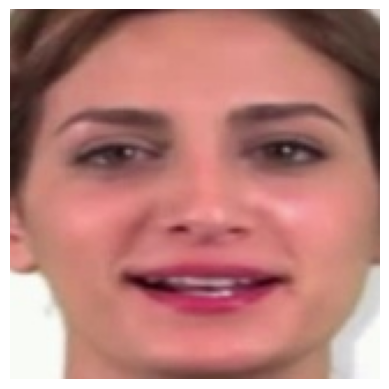

In [ ]:
import matplotlib.pyplot as plt
import random
import os
from PIL import Image

folder="/content/faces/train/real"

img=random.choice(os.listdir(folder))
image=Image.open(os.path.join(folder,img))

plt.imshow(image)
plt.axis("off")

In [ ]:
train_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2,contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],
                         [0.229,0.224,0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],
                         [0.229,0.224,0.225])
])

In [ ]:
train_dataset=datasets.ImageFolder("/content/faces/train",transform=train_transform)
val_dataset=datasets.ImageFolder("/content/faces/val",transform=val_transform)
test_dataset=datasets.ImageFolder("/content/faces/test",transform=val_transform)

print(train_dataset.class_to_idx)

{'fake': 0, 'real': 1}


In [ ]:
batch_size=32

train_loader=DataLoader(train_dataset,batch_size=batch_size,shuffle=True)
val_loader=DataLoader(val_dataset,batch_size=batch_size,shuffle=False)
test_loader=DataLoader(test_dataset,batch_size=batch_size,shuffle=False)

In [ ]:
model = timm.create_model("efficientnet_b0", pretrained=True)

in_features = model.classifier.in_features

model.classifier = nn.Sequential(
    nn.Linear(in_features, 512),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(512, 2)
)

model = model.to(device)

In [ ]:
criterion=nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(model.parameters(), lr=3e-4, weight_decay=1e-4)

In [ ]:
def validate(model,val_loader):

    model.eval()

    correct=0
    total=0

    with torch.no_grad():

        for images,labels in val_loader:

            images,labels=images.to(device),labels.to(device)

            outputs=model(images)

            _,predicted=torch.max(outputs,1)

            total+=labels.size(0)
            correct+=(predicted==labels).sum().item()

    val_accuracy = 100*correct/total
    print("Validation Accuracy:",val_accuracy)
    return val_accuracy

In [ ]:
best_acc = 0

def train_model(model, train_loader, val_loader, epochs):

    global best_acc

    for epoch in range(epochs):

        model.train()

        correct = 0
        total = 0

        for images, labels in train_loader:

            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()

            outputs = model(images)

            loss = criterion(outputs, labels)

            loss.backward()

            optimizer.step()

            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        train_acc = 100 * correct / total

        print("\nEpoch:", epoch + 1)
        print("Training Accuracy:", train_acc)

        # ---- Validation ----
        val_acc = validate(model, val_loader)

        # ---- Save Best Model ----
        if val_acc > best_acc:
            best_acc = val_acc
            torch.save(model.state_dict(), "best_deepfake_model.pth")
            print("✅ Best model saved with accuracy:", best_acc)

In [ ]:
train_model(model,train_loader,val_loader,11)


Epoch: 1
Training Accuracy: 99.3777307030319
Validation Accuracy: 88.16176470588235
✅ Best model saved with accuracy: 88.16176470588235

Epoch: 2
Training Accuracy: 97.25274725274726
Validation Accuracy: 81.25

Epoch: 3
Training Accuracy: 99.50350853965311
Validation Accuracy: 68.75

Epoch: 4
Training Accuracy: 98.57010459420098
Validation Accuracy: 81.69117647058823

Epoch: 5
Training Accuracy: 99.69548523765391
Validation Accuracy: 83.8970588235294

Epoch: 6
Training Accuracy: 99.61604660399841
Validation Accuracy: 83.08823529411765

Epoch: 7
Training Accuracy: 99.74182444061962
Validation Accuracy: 87.86764705882354

Epoch: 8
Training Accuracy: 99.60280683172249
Validation Accuracy: 85.73529411764706

Epoch: 9
Training Accuracy: 99.57632728717066
Validation Accuracy: 57.4264705882353

Epoch: 10
Training Accuracy: 98.17953131206143
Validation Accuracy: 86.98529411764706

Epoch: 11
Training Accuracy: 99.7285846683437
Validation Accuracy: 87.3529411764706


In [ ]:
print("Train real faces:",len(os.listdir("/content/faces/train/real")))
print("Train fake faces:",len(os.listdir("/content/faces/train/fake")))

Train real faces: 7546
Train fake faces: 7560


In [ ]:
def test_model(model,test_loader):

    model.eval()

    correct=0
    total=0

    with torch.no_grad():

        for images,labels in test_loader:

            images,labels=images.to(device),labels.to(device)

            outputs=model(images)

            _,predicted=torch.max(outputs,1)

            total+=labels.size(0)
            correct+=(predicted==labels).sum().item()

    print("Test Accuracy:",100*correct/total)

In [ ]:
test_model(model,test_loader)

Test Accuracy: 70.07352941176471


In [ ]:
import torch
import timm
import torch.nn as nn
from torchvision import transforms
from PIL import Image
import matplotlib.pyplot as plt

In [ ]:
import torch
import timm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# same architecture as training
model = timm.create_model("efficientnet_b0", pretrained=False, num_classes=2)

model.load_state_dict(torch.load("best_deepfake_model.pth", map_location=device))

model = model.to(device)
model.eval()

EfficientNet(
  (conv_stem): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
  (bn1): BatchNormAct2d(
    32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
    (drop): Identity()
    (act): SiLU(inplace=True)
  )
  (blocks): Sequential(
    (0): Sequential(
      (0): DepthwiseSeparableConv(
        (conv_dw): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
        (bn1): BatchNormAct2d(
          32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
          (drop): Identity()
          (act): SiLU(inplace=True)
        )
        (aa): Identity()
        (se): SqueezeExcite(
          (conv_reduce): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
          (act1): SiLU(inplace=True)
          (conv_expand): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
          (gate): Sigmoid()
        )
        (conv_pw): Conv2d(32, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn2

In [ ]:
transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],
                         [0.229,0.224,0.225])
])

In [ ]:
def predict_image(image_path):

    image = Image.open(image_path).convert("RGB")

    img = transform(image).unsqueeze(0).to(device)

    with torch.no_grad():
        outputs = model(img)
        probs = torch.softmax(outputs, dim=1)
        _, pred = torch.max(outputs,1)

    label = "FAKE" if pred.item()==0 else "REAL"

    confidence = probs[0][pred].item()

    plt.imshow(image)
    plt.title(f"{label} ({confidence:.2f})")
    plt.axis("off")

    return label, confidence

('REAL', 0.9943885207176208)

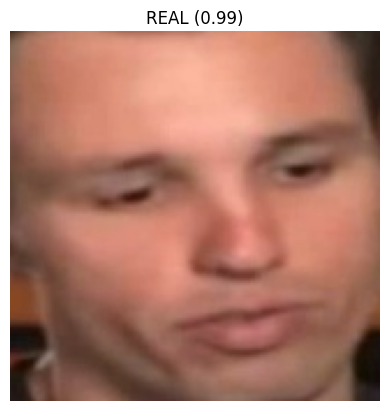

In [ ]:
predict_image("/content/faces/val/real/00268_0.jpg")

In [ ]:
import torch
import timm
import cv2
import numpy as np
from PIL import Image
from torchvision import transforms
from facenet_pytorch import MTCNN
import torch.nn as nn

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = timm.create_model("efficientnet_b0", pretrained=False, num_classes=2)

model.load_state_dict(torch.load("best_deepfake_model.pth", map_location=device))

model = model.to(device)
model.eval()

EfficientNet(
  (conv_stem): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
  (bn1): BatchNormAct2d(
    32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
    (drop): Identity()
    (act): SiLU(inplace=True)
  )
  (blocks): Sequential(
    (0): Sequential(
      (0): DepthwiseSeparableConv(
        (conv_dw): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
        (bn1): BatchNormAct2d(
          32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
          (drop): Identity()
          (act): SiLU(inplace=True)
        )
        (aa): Identity()
        (se): SqueezeExcite(
          (conv_reduce): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
          (act1): SiLU(inplace=True)
          (conv_expand): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
          (gate): Sigmoid()
        )
        (conv_pw): Conv2d(32, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn2

In [ ]:
mtcnn = MTCNN(keep_all=False, device=device)

In [ ]:
transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],
                         [0.229,0.224,0.225])
])

In [ ]:
import numpy as np
import cv2
from PIL import Image
import torch

def predict_video(video_path, frame_skip=3):

    cap = cv2.VideoCapture(video_path)

    predictions = []
    votes = []

    frame_count = 0

    while True:

        ret, frame = cap.read()

        if not ret:
            break

        if frame_count % frame_skip == 0:

            rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            image = Image.fromarray(rgb)

            face = mtcnn(image)

            if face is not None:

                face = face.permute(1,2,0).cpu().numpy()

                face = (face - face.min()) / (face.max() - face.min() + 1e-5)
                face = (face * 255).astype("uint8")

                face_img = Image.fromarray(face)

                img = transform(face_img).unsqueeze(0).to(device)

                with torch.no_grad():

                    outputs = model(img)

                    probs = torch.softmax(outputs, dim=1)

                    fake_prob = probs[0][0].item()

                    predictions.append(fake_prob)

                    # ignore uncertain frames
                    if fake_prob > 0.6:
                        votes.append(1)
                    elif fake_prob < 0.4:
                        votes.append(0)

        frame_count += 1

    cap.release()

    if len(predictions) == 0:
        print("No face detected")
        return "No face detected"

    # if too many frames were ignored, fallback to median
    if len(votes) == 0:
        # smooth frame predictions
        predictions = smooth_predictions(predictions)

        # weighted decision
        label, confidence = weighted_decision(predictions)

    else:
        fake_votes = sum(votes)
        real_votes = len(votes) - fake_votes

        label = "FAKE" if fake_votes > real_votes else "REAL"
        confidence = max(fake_votes, real_votes) / len(votes)

    print("Frames analyzed:", len(predictions))
    print("Frames used for decision:", len(votes))
    print("Prediction:", label)
    print("Confidence:", round(confidence,3))

    return label, confidence

In [ ]:
import numpy as np

def smooth_predictions(predictions, window=3):

    smoothed = []

    for i in range(len(predictions)):
        start = max(0, i-window)
        end = min(len(predictions), i+window)

        smoothed.append(np.mean(predictions[start:end]))

    return smoothed


def weighted_decision(predictions):

    weighted_sum = 0
    weight_total = 0

    for p in predictions:

        weight = abs(p - 0.5) * 2

        weighted_sum += p * weight
        weight_total += weight

    if weight_total == 0:
        avg_fake = np.mean(predictions)
    else:
        avg_fake = weighted_sum / weight_total

    label = "FAKE" if avg_fake > 0.5 else "REAL"

    confidence = avg_fake if label=="FAKE" else 1-avg_fake

    return label, confidence

In [ ]:
predict_video("/content/dataset/test/fake/id50_id57_0001.mp4")

Frames analyzed: 128
Frames used for decision: 124
Prediction: REAL
Confidence: 0.944


('REAL', 0.9435483870967742)

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    confusion_matrix,
    classification_report
)

import matplotlib.pyplot as plt
import numpy as np
import torch

def evaluate_model(model, test_loader):

    model.eval()

    y_true = []
    y_pred = []
    y_prob = []

    with torch.no_grad():

        for images, labels in test_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            probs = torch.softmax(outputs, dim=1)

            _, preds = torch.max(outputs, 1)

            y_true.extend(labels.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())
            y_prob.extend(probs[:,1].cpu().numpy())

    # metrics
    acc = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    auc = roc_auc_score(y_true, y_prob)

    print("Accuracy:", acc)
    print("Precision:", precision)
    print("Recall:", recall)
    print("F1 Score:", f1)
    print("AUC Score:", auc)

    print("\nClassification Report\n")
    print(classification_report(y_true, y_pred))

    # confusion matrix
    cm = confusion_matrix(y_true, y_pred)

    print("\nConfusion Matrix")
    print(cm)

    # ROC Curve
    fpr, tpr, thresholds = roc_curve(y_true, y_prob)

    plt.figure(figsize=(6,6))
    plt.plot(fpr, tpr, label="AUC = %.3f" % auc)
    plt.plot([0,1],[0,1],'--')
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve")
    plt.legend()
    plt.show()

Accuracy: 0.5507352941176471
Precision: 0.5267234701781565
Recall: 1.0
F1 Score: 0.6900050735667174
AUC Score: 0.8348410467128028

Classification Report

              precision    recall  f1-score   support

           0       1.00      0.10      0.18       680
           1       0.53      1.00      0.69       680

    accuracy                           0.55      1360
   macro avg       0.76      0.55      0.44      1360
weighted avg       0.76      0.55      0.44      1360


Confusion Matrix
[[ 69 611]
 [  0 680]]


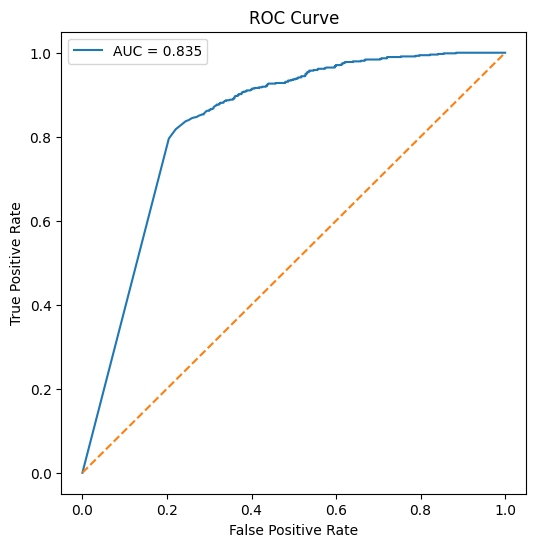

In [ ]:
evaluate_model(model, test_loader)

In [ ]:
import numpy as np
from sklearn.metrics import f1_score

thresholds = np.arange(0.1,0.9,0.05)

best_thr = 0
best_f1 = 0

for t in thresholds:

    preds = (np.array(y_prob) > t).astype(int)

    f1 = f1_score(y_true,preds)

    if f1 > best_f1:
        best_f1 = f1
        best_thr = t

print("Best threshold:",best_thr)
print("Best F1:",best_f1)

NameError: name 'y_prob' is not defined

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

def evaluate_model(model, test_loader):

    model.eval()

    y_true = []
    y_pred = []
    y_prob = []

    with torch.no_grad():

        for images, labels in test_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            probs = torch.softmax(outputs, dim=1)

            _, preds = torch.max(outputs, 1)

            y_true.extend(labels.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())
            y_prob.extend(probs[:,1].cpu().numpy())

    acc = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    auc = roc_auc_score(y_true, y_prob)

    print("Accuracy:", acc)
    print("Precision:", precision)
    print("Recall:", recall)
    print("F1 Score:", f1)
    print("AUC Score:", auc)

    return y_true, y_prob

In [ ]:
y_true, y_prob = evaluate_model(model, test_loader)

Accuracy: 0.5507352941176471
Precision: 0.5267234701781565
Recall: 1.0
F1 Score: 0.6900050735667174
AUC Score: 0.8348410467128028


In [ ]:
import numpy as np
from sklearn.metrics import f1_score

thresholds = np.arange(0.1, 0.9, 0.05)

best_thr = 0
best_f1 = 0

for t in thresholds:

    preds = (np.array(y_prob) > t).astype(int)

    f1 = f1_score(y_true, preds)

    if f1 > best_f1:
        best_f1 = f1
        best_thr = t

print("Best threshold:", best_thr)
print("Best F1:", best_f1)

Best threshold: 0.8500000000000002
Best F1: 0.7060052219321149
